In [15]:
import lgdo
import lh5
import numpy as np
import awkward as ak
import os
import re
from pygama.pargen import survival_fractions as sf

In [16]:
filepath = "/mnt/atlas02/users/leoli/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

pnum_cal = "00"
run_cal = "037"

pnum_phy_bg = "00"
run_phy_bg = "038"

pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
    's20ns_mw5',  's20ns_mw7',
    's30ns_mw3',  's30ns_mw5',  's30ns_mw7',
    's40ns_mw1',  's40ns_mw3',  's40ns_mw5',  's40ns_mw7',
    's50ns_mw1',  's50ns_mw3',  's50ns_mw5',  's50ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7',
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's300ns_mw1', 's300ns_mw3', 's300ns_mw5', 's300ns_mw7','s300ns_mw15',
    's500ns_mw1', 's500ns_mw3', 's500ns_mw5', 's500ns_mw7','s500ns_mw15',
    's700ns_mw1', 's700ns_mw3', 's700ns_mw5', 's700ns_mw7','s700ns_mw15',
]
def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)
        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")

        missing_this_run = []

        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")

        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "interval": f"{m.group(1)}ns",
            "mw": f"mw{m.group(2)}",

            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,

            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,

            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )

    return db
run_db = build_run_db(runs, filepath)
run_db['s100ns_mw5']["phy_bg_path"]

'/mnt/atlas02/users/leoli/scarf/sp01/data/hit_vcs/s100ns_mw5/phy/p00/r038'

In [3]:
import pickle
with open("/mnt/atlas02/users/leoli/AoverE_analysis/SEP_analysis/sf_results_cut90_linear_interpolation_all_50points.pkl", "rb") as f:
    sf_results = pickle.load(f)


In [4]:
run1 = 's100ns_mw5'
run2 = 's300ns_mw7'
pathlist = "cal_pathlist"

In [5]:

# fitrange_dep = (1565, 1615)
# peak_dep = 1592.5

# mask_dep = (
#     np.isfinite(energy_array)
#     & np.isfinite(aoe_array)
#     & (energy_array > fitrange_dep[0])
#     & (energy_array < fitrange_dep[1])
#     & is_valid_waveform)

# E_fit_dep = energy_array[mask_dep]
# aoe_fit_dep = aoe_array[mask_dep]

# print("E_fit_dep:", len(E_fit_dep))
# print("aoe_fit_dep:", len(aoe_fit_dep))


fitrange_sep = (2070, 2140)

peak_sep =2103.5


# mask_sep = (
#     np.isfinite(energy_array)
#     & np.isfinite(aoe_array)
#     & (energy_array > fitrange_sep[0])
#     & (energy_array < fitrange_sep[1])
#     & is_valid_waveform
# )

# E_fit_sep = energy_array[mask_sep]
# aoe_fit_sep = aoe_array[mask_sep]

# fitrange_fep =  (2580, 2645)
# peak_fep = 2614.5
# mask_fep = (
#     np.isfinite(energy_array)
#     & np.isfinite(aoe_array)
#     & (energy_array > fitrange_fep[0])
#     & (energy_array < fitrange_fep[1])
#     & is_valid_waveform
# )
# E_fit_fep = energy_array[mask_fep]
# aoe_fit_fep = aoe_array[mask_fep] 

In [6]:
def two_cuts(run1, run2):
## masks for dep sep fep
    fitrange_dep = (1565, 1615)
    peak_dep = 1592.5
    fitrange_sep = (2070, 2140)
    peak_sep =2103.5
    fitrange_fep =  (2580, 2645)
    peak_fep = 2614.5
    is_valid_waveform= lh5.read("ch002/hit/is_valid_waveform",run_db['s100ns_mw5'][pathlist])
    # run1 
    E_1=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run1][pathlist])
    # Iasy_std = lh5.read("ch002/hit/Iasy",run_db["s100ns_mw5"][pathlist])
    A_max_mw_o_E_Classifier_1=lh5.read("ch002/hit/A_max_mw_o_E_fix_Classifier",run_db[run1][pathlist])
    E_1 = np.asarray(E_1)
    E_2=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run2][pathlist])
    A_max_mw_o_E_Classifier_2=lh5.read("ch002/hit/A_max_mw_o_E_fix_Classifier",run_db[run2][pathlist])
    E_2 = np.asarray(E_2)
    # Iasy_std = np.asarray(Iasy_std)
    A_max_mw_o_E_Classifier_2= np.asarray(A_max_mw_o_E_Classifier_2)
    is_valid_waveform = np.asarray(is_valid_waveform)
    cut_value_1 = sf_results['cut_value_90'][run1]
    cut_value_2 = sf_results['cut_value_90'][run2]
    mask_dep_1 = (
        np.isfinite(E_1)
        & np.isfinite(A_max_mw_o_E_Classifier_1)
        & (E_1 > fitrange_dep[0])
        & (E_1 < fitrange_dep[1])
        & is_valid_waveform)
    mask_dep_2 = (
        np.isfinite(E_2)
        & np.isfinite(A_max_mw_o_E_Classifier_2)
        & (E_2 > fitrange_dep[0])
        & (E_2 < fitrange_dep[1])
        & is_valid_waveform)
    mask_sep_1 = (
        np.isfinite(E_1)
        & np.isfinite(A_max_mw_o_E_Classifier_1)
        & (E_1 > fitrange_sep[0])
        & (E_1 < fitrange_sep[1])
        & is_valid_waveform
        )
    mask_sep_2= (
        np.isfinite(E_2)
        & np.isfinite(A_max_mw_o_E_Classifier_2)
        & (E_2 > fitrange_sep[0])
        & (E_2 < fitrange_sep[1])
        & is_valid_waveform
        )
    mask_fep_1 = (
        np.isfinite(E_1)
        & np.isfinite(A_max_mw_o_E_Classifier_1)
        & (E_1 > fitrange_fep[0])
        & (E_1 < fitrange_fep[1])
        & is_valid_waveform
        )
    mask_fep_2= (
        np.isfinite(E_2)
        & np.isfinite(A_max_mw_o_E_Classifier_2)
        & (E_2 > fitrange_fep[0])
        & (E_2 < fitrange_fep[1])
        & is_valid_waveform
        )
    E_fit_dep = E_1[mask_dep_1]
    E_fit_sep = E_1[mask_sep_1]
    E_fit_fep = E_1[mask_fep_1]
    aoe_fit_dep_1 = A_max_mw_o_E_Classifier_1[mask_dep_1]
    aoe_fit_dep_2 = A_max_mw_o_E_Classifier_2[mask_dep_2]
    aoe_fit_sep_1 = A_max_mw_o_E_Classifier_1[mask_sep_1]
    aoe_fit_sep_2 = A_max_mw_o_E_Classifier_2[mask_sep_2]
    aoe_fit_fep_1 = A_max_mw_o_E_Classifier_1[mask_fep_1]
    aoe_fit_fep_2 = A_max_mw_o_E_Classifier_2[mask_fep_2]

    # DEP after two cuts
    sf_val_dep, sf_err_dep, _, _ = sf.get_survival_fraction_two_cuts(
        energy=E_fit_dep,
        cut_param_1=aoe_fit_dep_1,
        cut_param_2=aoe_fit_dep_2,
        cut_val_1=cut_value_1,
        cut_val_2=cut_value_2,
        peak=peak_dep,        # DEP peak
        fit_range=fitrange_dep,
        func=sf.hpge_peak,
        mode="greater",
        display=2,
        eres_pars=3
    )
    ## SEP after two cuts
    sf_val_sep, sf_err_sep, _, _ = sf.get_survival_fraction_two_cuts(
        energy=E_fit_sep,
        cut_param_1=aoe_fit_sep_1,
        cut_param_2=aoe_fit_sep_2,
        cut_val_1=cut_value_1,
        cut_val_2=cut_value_2,
        peak=peak_sep,        # SEP peak
        fit_range=fitrange_sep,
        func=sf.hpge_peak,
        mode="greater",
        display=1,
        eres_pars=3
    )
    sf_val_fep, sf_err_fep, _, _ = sf.get_survival_fraction_two_cuts(
        energy=E_fit_fep,
        cut_param_1=aoe_fit_fep_1,
        cut_param_2=aoe_fit_fep_2,
        cut_val_1=cut_value_1,
        cut_val_2=cut_value_2,
        peak=peak_fep,        # FEP peak
        fit_range=fitrange_fep,
        func=sf.hpge_peak,
        mode="greater",
        display=1,
        eres_pars=3
    )
    
    print("combining two cuts of"+run1+" and "+run2)
    # print(f"Survival fraction for DEP after two cuts: {sf_val_dep:.4f} ± {sf_err_dep:.4f}")
    print(f"Survival fraction for SEP after two cuts: {sf_val_sep:.4f} ± {sf_err_sep:.4f}")
    print(f"Survival fraction for FEP after two cuts: {sf_val_fep:.4f} ± {sf_err_fep:.4f}")
    return sf_val_sep, sf_err_sep, sf_val_fep, sf_err_fep


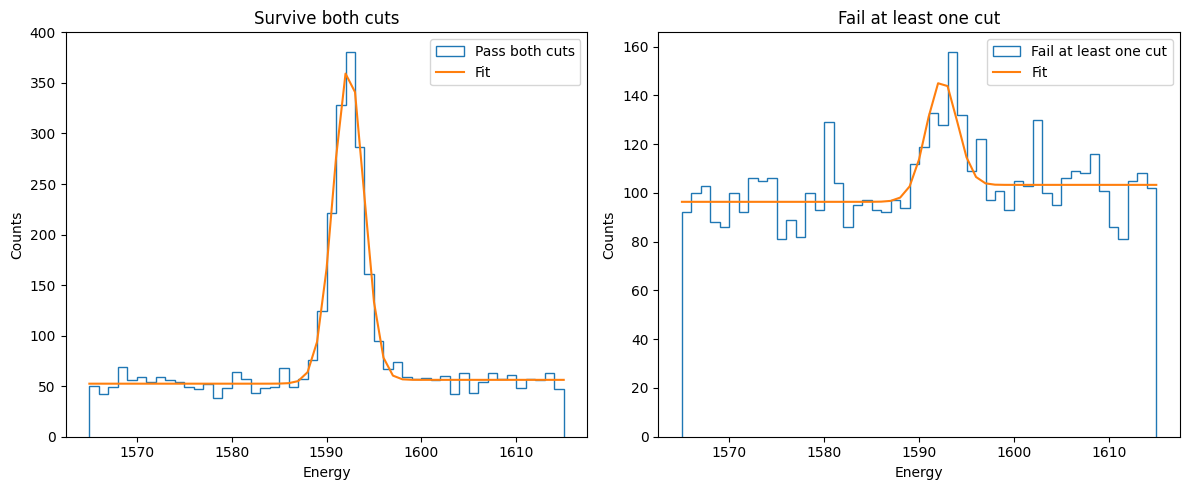

combining two cuts ofs100ns_mw5 and s300ns_mw7
Survival fraction for SEP after two cuts: 7.1428 ± 0.6332
Survival fraction for FEP after two cuts: 9.4255 ± 0.1563


In [7]:
sf_val_sep, sf_err_sep, sf_val_fep, sf_err_fep = two_cuts(run1, run2)

In [7]:
from itertools import product
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
sf_correlations = {}

for run1, run2 in product(runs, repeat=2):
    sf_val_sep, sf_err_sep, sf_val_fep, sf_err_fep = two_cuts(run1, run2)
    sf_correlations[(run1, run2)] = {
        "sep": (
            float(sf_val_sep),
            float(sf_err_sep),
        ),
        "fep": (
            float(sf_val_fep),
            float(sf_err_fep),
        ),
    }
    gc.collect()

combining two cuts ofs20ns_mw5 and s20ns_mw5
Survival fraction for SEP after two cuts: 10.1726 ± 0.7260
Survival fraction for FEP after two cuts: 17.3975 ± 0.2030
combining two cuts ofs20ns_mw5 and s20ns_mw7
Survival fraction for SEP after two cuts: 9.4374 ± 0.7110
Survival fraction for FEP after two cuts: 16.4655 ± 0.1986
combining two cuts ofs20ns_mw5 and s30ns_mw3
Survival fraction for SEP after two cuts: 8.9896 ± 0.7012
Survival fraction for FEP after two cuts: 15.2155 ± 0.1923
combining two cuts ofs20ns_mw5 and s30ns_mw5
Survival fraction for SEP after two cuts: 7.4560 ± 0.6652
Survival fraction for FEP after two cuts: 11.6604 ± 0.1718
combining two cuts ofs20ns_mw5 and s30ns_mw7
Survival fraction for SEP after two cuts: 6.8161 ± 0.6486
Survival fraction for FEP after two cuts: 10.4684 ± 0.1639
combining two cuts ofs20ns_mw5 and s40ns_mw1
Survival fraction for SEP after two cuts: 9.3727 ± 0.7075
Survival fraction for FEP after two cuts: 16.3232 ± 0.1979
combining two cuts ofs20ns_

In [8]:
import pickle
from pathlib import Path
outpath = Path("survival_correlations_simu_mse.pkl")

with open(outpath, "wb") as f:
    pickle.dump(sf_correlations, f)

print("saved to:", outpath.resolve())

sf_correlations

saved to: /mnt/atlas02/users/leoli/AoverE_analysis/two_aoe_cuts/survival_correlations_simu_mse.pkl


{('s20ns_mw5', 's20ns_mw5'): {'sep': (10.172563776641041, 0.7260135270975367),
  'fep': (17.39754512448832, 0.2029533848639145)},
 ('s20ns_mw5', 's20ns_mw7'): {'sep': (9.437378279811732, 0.7110240122245877),
  'fep': (16.46552019785481, 0.19855338680370982)},
 ('s20ns_mw5', 's30ns_mw3'): {'sep': (8.989621064098166, 0.7011611955727991),
  'fep': (15.215540270525905, 0.19229070073864402)},
 ('s20ns_mw5', 's30ns_mw5'): {'sep': (7.456020570819268, 0.6651896990241962),
  'fep': (11.660424693270173, 0.1718457087907868)},
 ('s20ns_mw5', 's30ns_mw7'): {'sep': (6.816068529474515, 0.6486178213713559),
  'fep': (10.468391641330829, 0.16392431915351127)},
 ('s20ns_mw5', 's40ns_mw1'): {'sep': (9.372712023477856, 0.707456198220531),
  'fep': (16.323173446207157, 0.19786808279046997)},
 ('s20ns_mw5', 's40ns_mw3'): {'sep': (7.091070269383885, 0.6547298352155235),
  'fep': (10.916058344295504, 0.1669651625634594)},
 ('s20ns_mw5', 's40ns_mw5'): {'sep': (6.431477107210581, 0.6347655882147158),
  'fep': (

In [1]:
import pickle
with open("/mnt/atlas02/users/leoli/AoverE_analysis/two_aoe_cuts/survival_correlations_simu_mse.pkl", "rb") as f:
    sf_correlations = pickle.load(f)
sf_correlations.keys()


dict_keys([('s20ns_mw5', 's20ns_mw5'), ('s20ns_mw5', 's20ns_mw7'), ('s20ns_mw5', 's30ns_mw3'), ('s20ns_mw5', 's30ns_mw5'), ('s20ns_mw5', 's30ns_mw7'), ('s20ns_mw5', 's40ns_mw1'), ('s20ns_mw5', 's40ns_mw3'), ('s20ns_mw5', 's40ns_mw5'), ('s20ns_mw5', 's40ns_mw7'), ('s20ns_mw5', 's50ns_mw1'), ('s20ns_mw5', 's50ns_mw3'), ('s20ns_mw5', 's50ns_mw5'), ('s20ns_mw5', 's50ns_mw7'), ('s20ns_mw5', 's60ns_mw1'), ('s20ns_mw5', 's60ns_mw3'), ('s20ns_mw5', 's60ns_mw5'), ('s20ns_mw5', 's60ns_mw7'), ('s20ns_mw5', 's100ns_mw1'), ('s20ns_mw5', 's100ns_mw3'), ('s20ns_mw5', 's100ns_mw5'), ('s20ns_mw5', 's100ns_mw7'), ('s20ns_mw5', 's200ns_mw1'), ('s20ns_mw5', 's200ns_mw3'), ('s20ns_mw5', 's200ns_mw5'), ('s20ns_mw5', 's200ns_mw7'), ('s20ns_mw5', 's300ns_mw1'), ('s20ns_mw5', 's300ns_mw3'), ('s20ns_mw5', 's300ns_mw5'), ('s20ns_mw5', 's300ns_mw7'), ('s20ns_mw5', 's300ns_mw15'), ('s20ns_mw5', 's500ns_mw1'), ('s20ns_mw5', 's500ns_mw3'), ('s20ns_mw5', 's500ns_mw5'), ('s20ns_mw5', 's500ns_mw7'), ('s20ns_mw5', 's500

## heatmaps

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Runs displayed on the x-axis
x_runs = [
    "s30ns_mw3",
    "s30ns_mw5",
    "s30ns_mw7",
    "s40ns_mw1",
    "s40ns_mw3",
    "s40ns_mw5",
    "s40ns_mw7",
    "s50ns_mw1",
    "s50ns_mw3",
    "s50ns_mw5",
    "s50ns_mw7",
    "s60ns_mw1",
    "s60ns_mw3",
    "s60ns_mw5",
    "s60ns_mw7",
]

# Runs displayed on the y-axis
y_runs = [
    "s200ns_mw3",
    "s200ns_mw5",
    "s200ns_mw7",
    "s300ns_mw3",
    "s300ns_mw5",
    "s300ns_mw7",
    "s500ns_mw3",
    "s500ns_mw5",
    "s500ns_mw7",
]


n_x = len(x_runs)
n_y = len(y_runs)

# Rows correspond to y_runs; columns correspond to x_runs.
sf_values = np.full((n_y, n_x), np.nan, dtype=float)
sf_errors = np.full((n_y, n_x), np.nan, dtype=float)
annotations = np.full((n_y, n_x), "", dtype=object)


for i, y_run in enumerate(y_runs):
    for j, x_run in enumerate(x_runs):

        # This assumes sf_correlations keys are ordered as:
        # (y-axis run, x-axis run)
        result = sf_correlations.get((y_run, x_run))

        if result is None:
            continue

        value, error = result

        sf_values[i, j] = value
        sf_errors[i, j] = error
        annotations[i, j] = f"{value:.2f}\n± {error:.3f}"


# Hide combinations that are absent from sf_correlations.
missing_mask = np.isnan(sf_values)

fig_width = max(12, 1.2 * n_x)
fig_height = max(8, 1.0 * n_y)

fig, ax = plt.subplots(
    figsize=(fig_width, fig_height)
)

sns.heatmap(
    sf_values,
    annot=annotations,
    fmt="",
    mask=missing_mask,
    xticklabels=x_runs,
    yticklabels=y_runs,
    cmap="viridis",
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"fontsize": 10},
    cbar_kws={"label": "Survival fraction (%)"},
)

ax.set_xlabel("Run 1")
ax.set_ylabel("Run 2")
ax.set_title("Survival-fraction correlations")

ax.tick_params(axis="x", labelrotation=45, labelsize=10)
ax.tick_params(axis="y", labelrotation=0, labelsize=10)

# Align the rotated x labels.
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'sep'

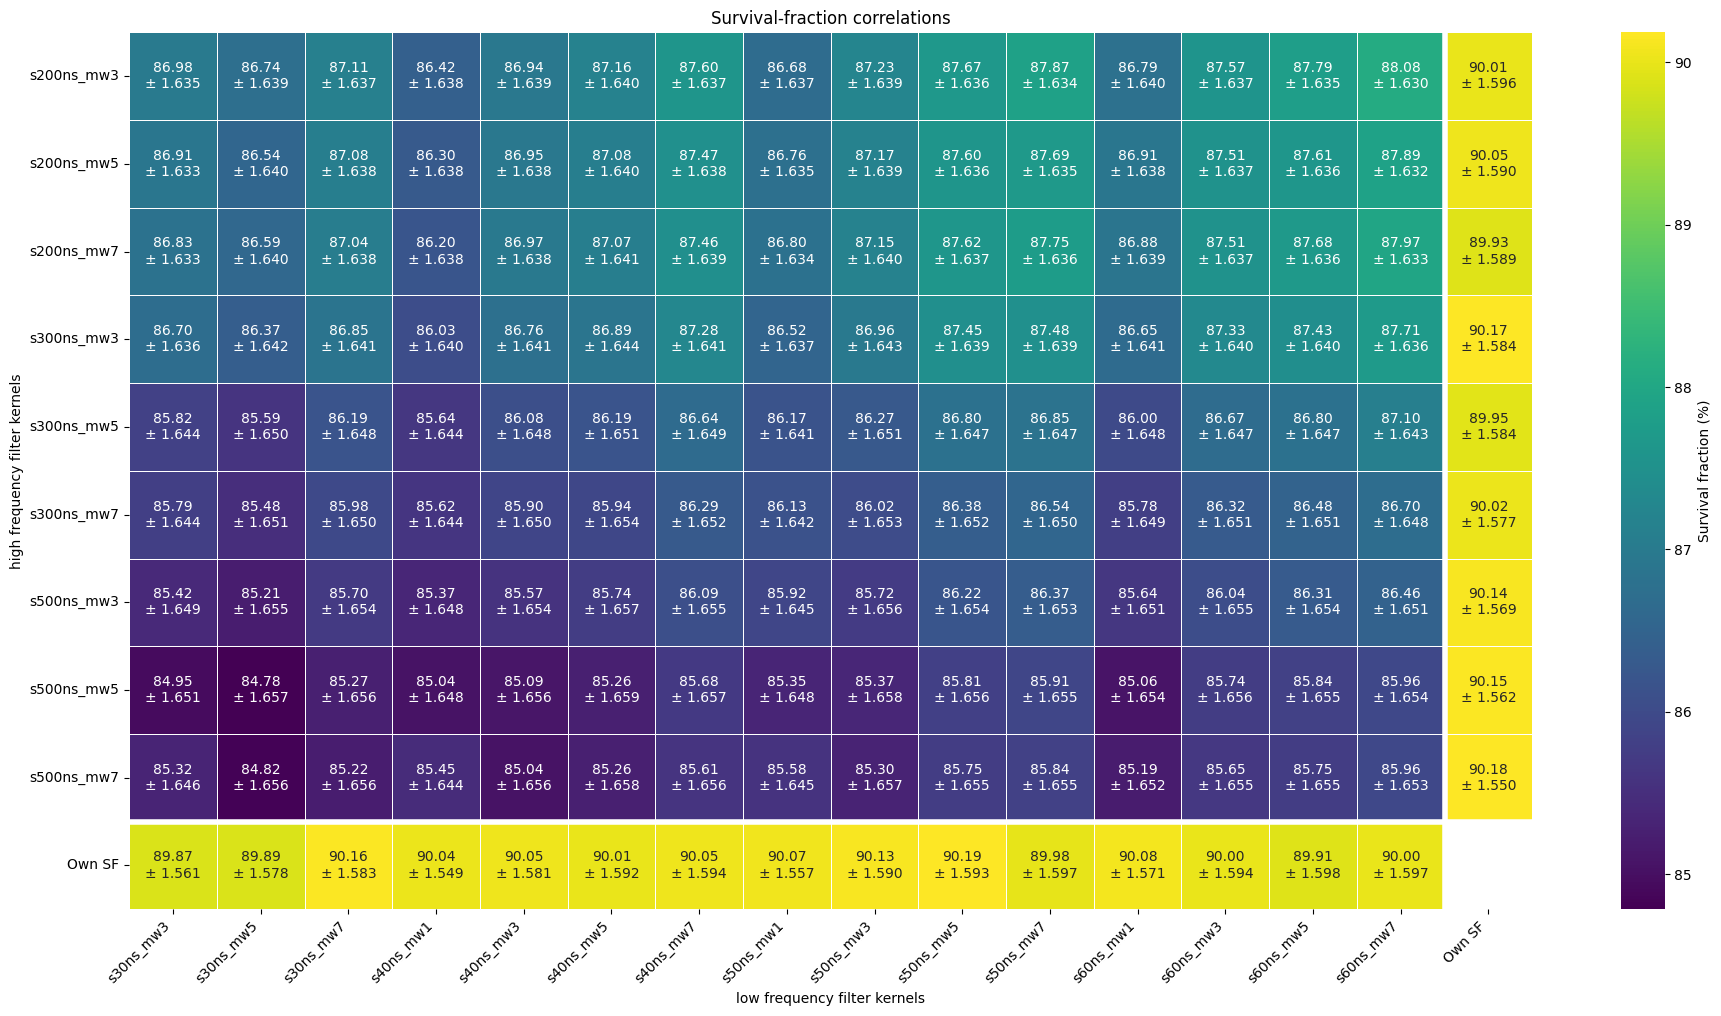

In [20]:
n_x = len(x_runs)
n_y = len(y_runs)

# Add one extra row and one extra column.
sf_values = np.full((n_y + 1, n_x + 1), np.nan, dtype=float)
sf_errors = np.full((n_y + 1, n_x + 1), np.nan, dtype=float)
annotations = np.full((n_y + 1, n_x + 1), "", dtype=object)


# Main correlation matrix.
for i, y_run in enumerate(y_runs):
    for j, x_run in enumerate(x_runs):

        # Change the order here if your dictionary uses (x_run, y_run).
        result = sf_correlations.get((y_run, x_run))

        if result is None:
            continue

        value, error = result

        sf_values[i, j] = value
        sf_errors[i, j] = error
        annotations[i, j] = f"{value:.2f}\n± {error:.3f}"


# Extra bottom row: own SF for every x-axis run.
for j, x_run in enumerate(x_runs):
    result = sf_correlations.get((x_run, x_run))

    if result is None:
        continue

    value, error = result

    sf_values[n_y, j] = value
    sf_errors[n_y, j] = error
    annotations[n_y, j] = f"{value:.2f}\n± {error:.3f}"


# Extra right column: own SF for every y-axis run.
for i, y_run in enumerate(y_runs):
    result = sf_correlations.get((y_run, y_run))

    if result is None:
        continue

    value, error = result

    sf_values[i, n_x] = value
    sf_errors[i, n_x] = error
    annotations[i, n_x] = f"{value:.2f}\n± {error:.3f}"


# The bottom-right corner remains empty because it does not correspond
# to a particular run.
x_labels = x_runs + ["Own SF"]
y_labels = y_runs + ["Own SF"]

missing_mask = np.isnan(sf_values)

fig_width = max(12, 1.2 * (n_x + 1))
fig_height = max(8, 1.0 * (n_y + 1))

fig, ax = plt.subplots(
    figsize=(fig_width, fig_height)
)

sns.heatmap(
    sf_values,
    annot=annotations,
    fmt="",
    mask=missing_mask,
    xticklabels=x_labels,
    yticklabels=y_labels,
    cmap="viridis",
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"fontsize": 10},
    cbar_kws={"label": "Survival fraction (%)"},
)

# Separate the own-SF row and column visually.
ax.axhline(n_y, color="white", linewidth=4)
ax.axvline(n_x, color="white", linewidth=4)

ax.set_xlabel("low frequency filter kernels")
ax.set_ylabel("high frequency filter kernels")
ax.set_title("Survival-fraction correlations")

ax.tick_params(axis="x", labelrotation=45, labelsize=10)
ax.tick_params(axis="y", labelrotation=0, labelsize=10)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

plt.tight_layout()
plt.show()

## heatmap with prominence and mse SF

In [27]:
import pickle
with open("/mnt/atlas02/users/leoli/AoverE_analysis/two_aoe_cuts/survival_correlations_simu_mse.pkl", "rb") as f:
    sf_correlations = pickle.load(f)
# sf_correlations.keys()

for i, y_run in enumerate(runs):
    for j, x_run in enumerate(runs):

        # This assumes sf_correlations keys are ordered as:
        # (y-axis run, x-axis run)
        sf_correlations[(y_run, x_run)] = sf_correlations[(y_run, x_run)].get("sep")

In [28]:
with open("/mnt/atlas02/users/leoli/AoverE_analysis/both_sided_cuts/pvr_db.pkl", "rb") as f:
    pvr_db = pickle.load(f)

# pvr_db['runs']
pvr_db['s300ns_mw3']["ch002"]["summary"]['ratio_gaussian']
pvr_db['s300ns_mw3']["ch002"]["summary"]['ratio_gaussian_err']

0.03537305862778958

In [29]:
with open("/mnt/atlas02/users/leoli/AoverE_analysis/SEP_analysis/sf_results_cut90_linear_interpolation_all_50points.pkl","rb") as f:
    sf_yaml = pickle.load(f)
sf_yaml['sep_sfs']['s20ns_mw5']

(10.172563776641041, 0.7260135270975367)

In [30]:
x_runs = [
    "s30ns_mw3",
    "s30ns_mw5",
    "s30ns_mw7",
    "s40ns_mw1",
    "s40ns_mw3",
    "s40ns_mw5",
    "s40ns_mw7",
    "s50ns_mw1",
    "s50ns_mw3",
    "s50ns_mw5",
    "s50ns_mw7",
    "s60ns_mw1",
    "s60ns_mw3",
    "s60ns_mw5",
    "s60ns_mw7",
]

# Runs displayed on the y-axis
y_runs = [
    "s200ns_mw1",
    "s200ns_mw3",
    "s200ns_mw5",
    "s200ns_mw7",
    "s300ns_mw1",
    "s300ns_mw3",
    "s300ns_mw5",
    "s300ns_mw7",
    "s500ns_mw1",
    "s500ns_mw3",
    "s500ns_mw5",
    "s500ns_mw7",
]


In [33]:
identity_results_x = {
    # x_run: (value, uncertainty)
}
identity_results_y = {
    # y_run: (value, uncertainty)
}

for x_run in x_runs:
    identity_results_x[x_run] = sf_yaml['fep_sfs'][x_run]
for y_run in y_runs:
    try:
        identity_results_y[y_run] = (pvr_db[y_run]["ch002"]["summary"]['ratio_gaussian'], pvr_db[y_run]["ch002"]["summary"]['ratio_gaussian_err'])
    except KeyError:
        identity_results_y[y_run] = (0,0)

In [34]:
n_x = len(x_runs)
n_y = len(y_runs)

shape = (n_y + 2, n_x + 2)

sf_layer = np.full(shape, np.nan)
identity_x_layer = np.full(shape, np.nan)
identity_y_layer = np.full(shape, np.nan)

sf_annotations = np.full(shape, "", dtype=object)
identity_x_annotations = np.full(shape, "", dtype=object)
identity_y_annotations = np.full(shape, "", dtype=object)


# Main correlation matrix
for i, y_run in enumerate(y_runs):
    for j, x_run in enumerate(x_runs):
        result = sf_correlations.get((y_run, x_run))

        if result is None:
            continue

        value, error = result
        sf_layer[i, j] = value
        sf_annotations[i, j] = f"{value:.2f}\n± {error:.3f}"


# Own SF for x-runs: bottom row
for j, x_run in enumerate(x_runs):
    result = sf_correlations.get((x_run, x_run))

    if result is None:
        continue

    value, error = result
    sf_layer[n_y, j] = value
    sf_annotations[n_y, j] = f"{value:.2f}\n± {error:.3f}"


# Own SF for y-runs: right column
for i, y_run in enumerate(y_runs):
    result = sf_correlations.get((y_run, y_run))

    if result is None:
        continue

    value, error = result
    sf_layer[i, n_x] = value
    sf_annotations[i, n_x] = f"{value:.2f}\n± {error:.3f}"


# X identity results: second bottom row
for j, x_run in enumerate(x_runs):
    result = identity_results_x.get(x_run)

    if result is None:
        continue

    value, error = result
    identity_x_layer[n_y + 1, j] = value
    identity_x_annotations[n_y + 1, j] = (
        f"{value:.2f}\n± {error:.3f}"
    )


# Y identity results: second right column
for i, y_run in enumerate(y_runs):
    result = identity_results_y.get(y_run)

    if result is None:
        continue

    value, error = result
    identity_y_layer[i, n_x + 1] = value
    identity_y_annotations[i, n_x + 1] = (
        f"{value:.2f}\n± {error:.3f}"
    )


x_labels = x_runs + ["Own SF", "Identity Y"]
y_labels = y_runs + ["Own SF", "Identity X"]

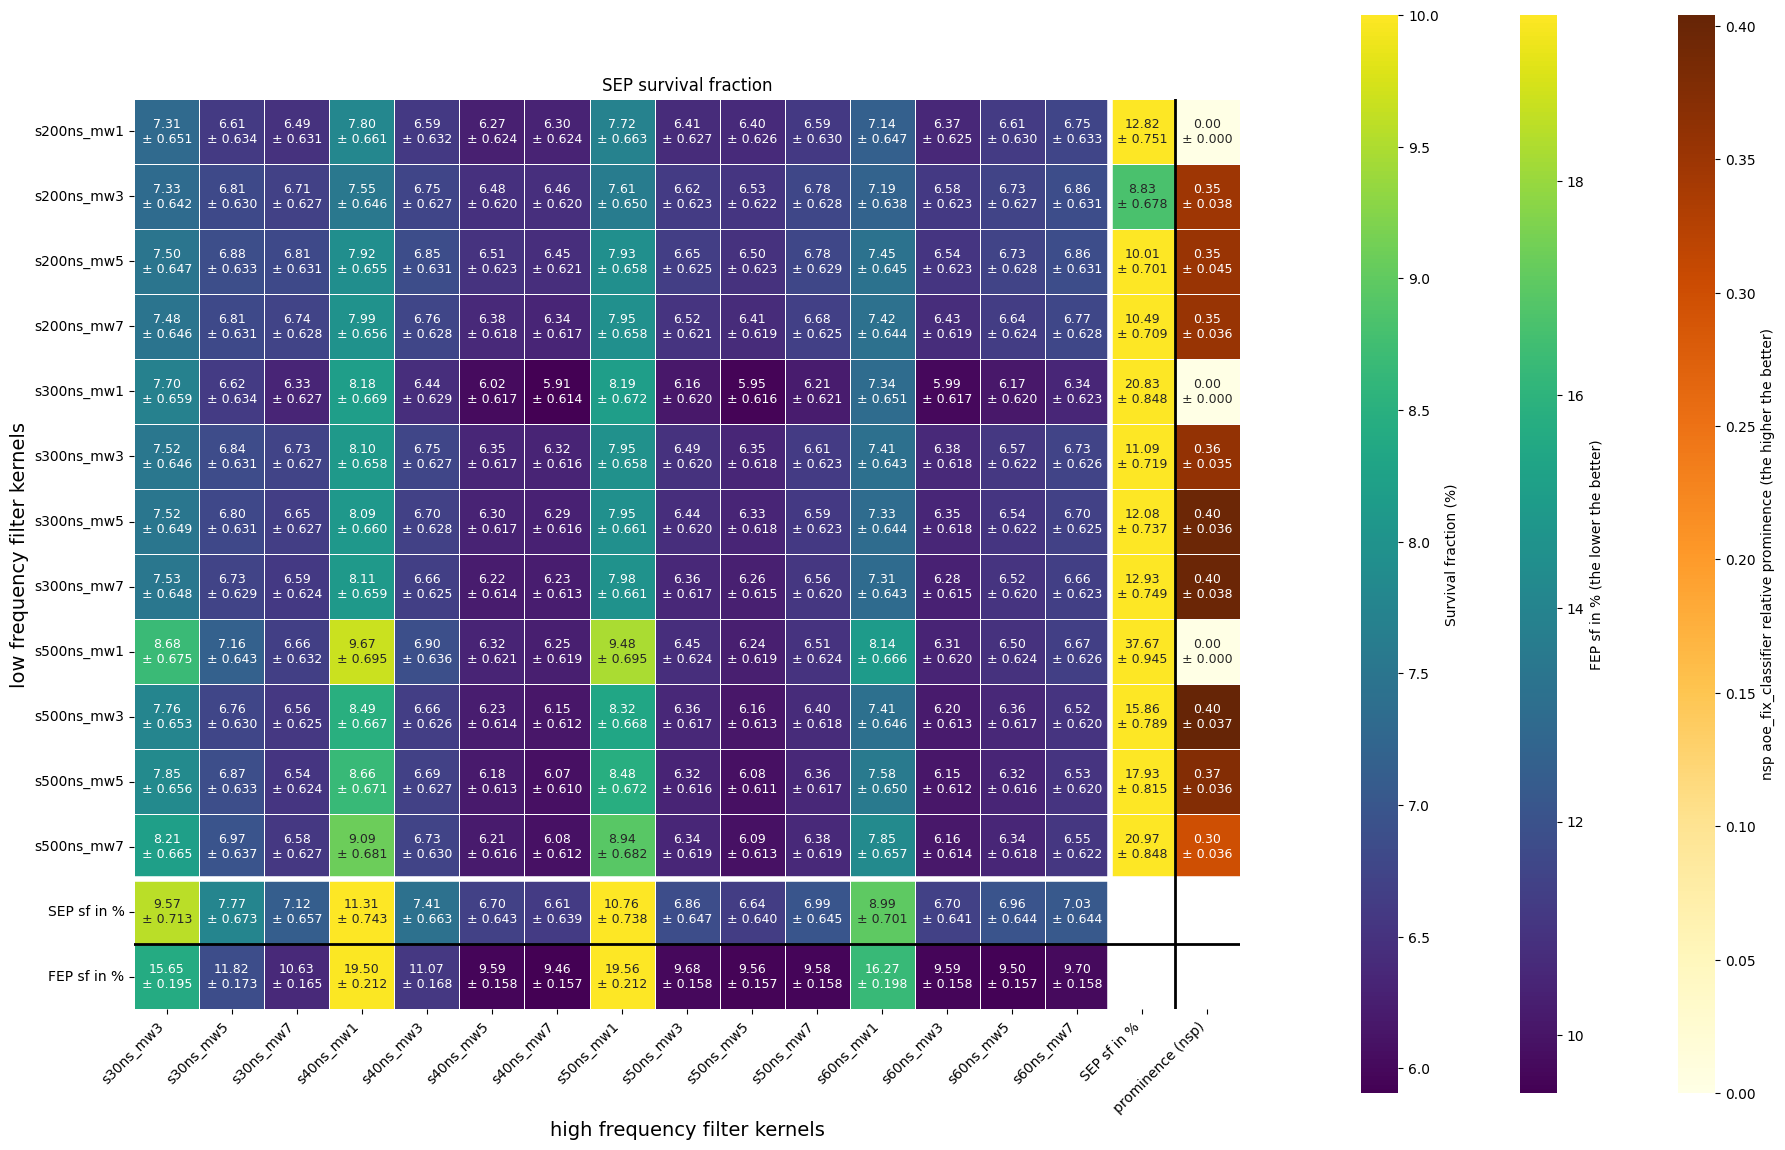

In [36]:
fig_width = max(15, 1.2 * (n_x + 2))
fig_height = max(9, 1.0 * (n_y + 2))

fig = plt.figure(figsize=(fig_width, fig_height))

grid = fig.add_gridspec(
    1,
    4,
    width_ratios=[30, 1, 1, 1],
    wspace=0.4,
)

ax = fig.add_subplot(grid[0, 0])

sf_cbar_ax = fig.add_subplot(grid[0, 1])
identity_x_cbar_ax = fig.add_subplot(grid[0, 2])
identity_y_cbar_ax = fig.add_subplot(grid[0, 3])


# SF layer
sns.heatmap(
    sf_layer,
    mask=np.isnan(sf_layer),
    annot=sf_annotations,
    fmt="",
    cmap="viridis",
    xticklabels=x_labels,
    yticklabels=y_labels,
    linewidths=0.5,
    vmax=10,
    # vmin=0,
    square=True,
    ax=ax,
    cbar_ax=sf_cbar_ax,
    cbar_kws={"label": "Survival fraction (%)"},
    annot_kws={"fontsize": 9},
)


# X identity layer
sns.heatmap(
    identity_x_layer,
    mask=np.isnan(identity_x_layer),
    annot=identity_x_annotations,
    fmt="",
    cmap="viridis",
    xticklabels=False,
    yticklabels=False,
    linewidths=0.5,
    square=True,
    ax=ax,
    cbar_ax=identity_x_cbar_ax,
    cbar_kws={"label": "FEP sf in % (the lower the better)"},
    annot_kws={
        "fontsize": 9,
    },
)


# Y identity layer
sns.heatmap(
    identity_y_layer,
    mask=np.isnan(identity_y_layer),
    annot=identity_y_annotations,
    fmt="",
    cmap="YlOrBr",
    xticklabels=False,
    yticklabels=False,
    linewidths=0.5,
    square=True,
    ax=ax,
    cbar_ax=identity_y_cbar_ax,
    cbar_kws={"label": "nsp aoe_fix_classifier relative prominence (the higher the better)"},
    annot_kws={
        "fontsize": 9,
    },
)


# Separation lines
ax.axhline(n_y, color="white", linewidth=4)
ax.axvline(n_x, color="white", linewidth=4)

ax.axhline(n_y + 1, color="black", linewidth=2)
ax.axvline(n_x + 1, color="black", linewidth=2)

ax.set_title("SEP survival fraction")

ax.tick_params(axis="x", labelrotation=45, labelsize=10)
ax.tick_params(axis="y", labelrotation=0, labelsize=10)
# Columns:
# x-runs, own SF of y-runs, identity of y-runs
x_labels = x_runs + [
    "SEP sf in %",
    "prominence (nsp)",
]

# Rows:
# y-runs, own SF of x-runs, identity of x-runs
y_labels = y_runs + [
    "SEP sf in %",
    "FEP sf in %",
]
# Put tick marks at the center of each heatmap cell.
ax.set_xticks(np.arange(len(x_labels)) + 0.5)
ax.set_yticks(np.arange(len(y_labels)) + 0.5)

# Add run names and extra row/column labels.
ax.set_xticklabels(
    x_labels,
    rotation=45,
    ha="right",
    fontsize=10,
)

ax.set_yticklabels(
    y_labels,
    rotation=0,
    fontsize=10,
)

# General axis labels.
ax.set_xlabel(
    "high frequency filter kernels",
    fontsize=14,
)

ax.set_ylabel(
    "low frequency filter kernels",
    fontsize=14,
)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

plt.show()